# Exercises week 38

##### **Group: Pernille Xu Amundsen, Maria Andersen and Hannah Westgaard**

**FYS-STK3155/4155, fall 2026 — deadline Friday September 18 at midnight.**

## Adaptive learning rates and stochastic gradient descent

The aim this week is that you extend last week's gradient descent code with
the adaptive methods AdaGrad, RMSProp and Adam, that you understand what each
of them does to the step and why their learning rate is not the learning rate
of plain gradient descent, and that you replace the full gradient by a
minibatch gradient with epochs and a learning-rate schedule. Everything here is
reused directly in parts f) and h) of Project 1. The code developed in the
Tuesday session (`week38tuesday.ipynb`, Cases 1 and 2) is meant to be reused,
and the Monday notebook (`week38.ipynb`) contains worked examples of every
piece.

After completing these exercises you will have

* derived the bias correction of Adam and the first step of the adaptive
  methods, and shown why they are insensitive to the scale of a feature;
* your own implementation of AdaGrad, RMSProp and Adam in the same
  three-function structure as last week's gradient descent, checked against
  the closed-form solutions of OLS and Ridge;
* scanned the learning rate for each method and related the windows you find
  to $2/\lambda_{\max}$ (Section 4.5) and to what $\gamma$ means for an
  adaptive method (Sections 4.8–4.12);
* a stochastic gradient descent loop with minibatches, epochs and the
  schedule of Eq. (4.40), and studied the batch size and the schedule
  (Section 4.7);
* applied all of it to the Runge function at degree 10, the problem nothing
  converged on last week.

Reading: Chapter 4, Sections 4.7–4.13 of the book; Goodfellow et al.,
Sections 8.1–8.5.

## The data

We keep last week's function,

$$
f(x) = 2 - x + 5x^2, \qquad x \in [-2, 2],
$$

with $n = 100$ points and Gaussian noise of standard deviation $0.5$, fitted
with polynomial features of degree 2 (an easy problem, $\kappa \approx 1.3$)
and degree 5 (a hard one, $\kappa \approx 520$). As last week, standardise the
columns of the design matrix, centre $\boldsymbol{y}$ and use no intercept
column; the closed-form OLS and Ridge solutions are your reference.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def exercise_data(n=100, degree=2, noise=0.5, seed=2026):
    """Standardised polynomial design matrix (no intercept column) and centred targets."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-2.0, 2.0, n)
    y = 2.0 - x + 5.0 * x**2 + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()

def closed_form(X, y, lam=0.0):
    """(X^T X + n lambda I)^-1 X^T y, the 1/n convention of Eq. (3.95)."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)

def cost(theta, X, y, lam=0.0):
    """Eqs. (4.12) and (4.16)."""
    return np.sum((X @ theta - y) ** 2) / len(y) + lam * theta @ theta

def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): your analytical gradient from last week (or jax.grad of cost)."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta

def hessian_eigs(X, lam=0.0):
    n = len(X)
    return np.linalg.eigvalsh((2.0 / n) * X.T @ X + 2.0 * lam * np.eye(X.shape[1]))

X2, y2 = exercise_data(degree=2)
X5, y5 = exercise_data(degree=5)
for X in (X2, X5):
    eigs = hessian_eigs(X)
    print(f"degree {X.shape[1]}: kappa = {eigs.max() / eigs.min():.1f}, 2/lambda_max = {2 / eigs.max():.3f}")

degree 2: kappa = 1.3, 2/lambda_max = 0.894
degree 5: kappa = 520.3, 2/lambda_max = 0.354


## Exercise 1: what the adaptive methods do to the step (analytical)

The three adaptive methods replace the single learning rate $\gamma$ by a
per-coordinate step $\gamma/\sqrt{v_j}$, where $v_j$ estimates the second
moment of the gradient in coordinate $j$ (Section 4.8).

### 1a)

Unroll the RMSProp recursion of Eq. (4.47),
$\boldsymbol{v}_t = \rho\,\boldsymbol{v}_{t-1} + (1-\rho)\boldsymbol{g}_t^2$ with
$\boldsymbol{v}_0 = \boldsymbol{0}$, to obtain Eq. (4.49),
$\boldsymbol{v}_t = (1-\rho)\sum_{j=1}^{t}\rho^{\,t-j}\boldsymbol{g}_j^2$, and show
that the weights sum to $1 - \rho^t$. After how many steps has a gradient's
weight fallen below $1/e$ of its initial weight, for $\rho = 0.9$ and
$\rho = 0.99$? Compare with AdaGrad's sum, Eq. (4.42), whose weights are all
one.

In [2]:
steps = 150
rhos = [0.9, 0.99]

for rho in rhos:
    for t in range(1,steps+1):
        weight_grad = rho**t
        if weight_grad < 1/np.e:
            print(f'For Rho = {rho}. Weight falls below 1/e at step {t}')
            break


For Rho = 0.9. Weight falls below 1/e at step 10
For Rho = 0.99. Weight falls below 1/e at step 100


### 1b)

Now Adam. Assume the gradient is stationary with $\mathbb{E}[g^2]$ constant.
Take the expectation of the unrolled second moment of Eq. (4.52) and derive
Eq. (4.53), $\mathbb{E}[v_t] = (1-\beta_2^{\,t})\,\mathbb{E}[g^2]$. Do the same
for the first moment with $\beta_1$. Explain why dividing by $1-\beta_i^t$,
Eq. (4.54), removes the bias exactly, and evaluate the correction factors at
$t = 1$, $t = 10$ and $t = 1000$ for the default $\beta_1 = 0.9$,
$\beta_2 = 0.999$.

From correction factors below we see that correction is 1 for $\beta_1 = 0.9$ at t=1000 and 0.632 for $beta_2 = 0.999$. Which holds for our theory as we see that the larger t becomes, the closer the correction factor will approach 0, i.e the less it will impact the iterations.  

In [3]:
ts = [1,10,1000]
betas = [0.9,0.999]

for beta in betas:
    for t in ts:
        corr_fact = 1-beta**t
        print(f'For beta = {beta} the correction factor at t = {t} is {corr_fact:.3f}')

For beta = 0.9 the correction factor at t = 1 is 0.100
For beta = 0.9 the correction factor at t = 10 is 0.651
For beta = 0.9 the correction factor at t = 1000 is 1.000
For beta = 0.999 the correction factor at t = 1 is 0.001
For beta = 0.999 the correction factor at t = 10 is 0.010
For beta = 0.999 the correction factor at t = 1000 is 0.632


### 1c)

Show that the first step of Adam, Eq. (4.55) at $t = 1$, is
$\Delta\theta_j = -\gamma\,\mathrm{sign}(g_{1,j})$ (up to $\epsilon$),
independent of the size of the gradient, and that the same holds for AdaGrad.
What is the first step of RMSProp, which has no bias correction, with
$\rho = 0.99$? What does this tell you about the meaning of $\gamma$ for these
methods, compared with plain gradient descent? Without bias correction, by
what factor would Adam's first step be too long?


In [4]:
Adam_too_long = (1-betas[0])/np.sqrt(1-betas[1])
print(f'First step in Adam without bias correction would be {Adam_too_long:.4f} too long.')

First step in Adam without bias correction would be 3.1623 too long.


### 1d)

Multiply one feature (one column of $\boldsymbol{X}$) by a constant $c$. Show
that the corresponding component of the gradient of the OLS cost scales by
$c$ and that the AdaGrad/RMSProp/Adam step in that coordinate is unchanged,
whereas the plain gradient descent step scales by $c$ (and the stability bound
$2/\lambda_{\max}$ moves). Why does this *not* mean that standardising the
data is unnecessary for the adaptive methods? (Hint: the Tuesday session's
rotated bowl.)

## Exercise 2: implementing AdaGrad, RMSProp and Adam

Extend last week's code with one step function that holds all five
optimisers. The template below has the update rules to fill in; keep the
gradient as an argument so that the analytical gradient and `jax.grad` are
interchangeable, as in part e) of Project 1.

In [5]:
"""Based on Tuesday seminar code but little tweaks to match Lecturebook notation"""
def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t = 1, 2, ...; state carries the running quantities."""
    if method == "plain":                                    # Eq. (4.10)
        return theta - gamma * g, state
    if method == "momentum":                                 # Eq. (4.28)
        v = beta * state.get('v', 0.0) + gamma * g
        state["v"] = v 
        return theta - v, state
    if method == "adagrad":                                  # Eqs. (4.42) and (4.45)
        r = state.get('r', 0.0) + g * g
        state["r"] = r
        return theta - (gamma/(np.sqrt(r + eps))) * g, state
    if method == "rmsprop":                                  # Eqs. (4.47) and (4.48)
        v = rho*state.get('v', 0.0) + (1 - rho)* g * g
        state["v"] = v 
        return theta - (gamma/(np.sqrt(v + eps))) * g, state
    if method == "adam":                                     # Eqs. (4.51), (4.52), (4.54), (4.55)
        m = beta1 * state.get('m', 0.0) + (1 - beta1) * g
        v = beta2 * state.get('v', 0.0) + (1 - beta2) * g * g
        state["m"] = m 
        state["v"] = v 
        m_hat, v_hat = m / (1- beta1**t), v/(1 - beta2**t)
        return theta - (gamma/(np.sqrt(v_hat) + eps)) * m_hat, state
    raise ValueError(f"unknown method {method}")

def optimise(grad, theta0, method, gamma, num_iters=1000, tol=1e-8, **kw):
    """Full-gradient loop; returns all iterates and the number of steps taken."""
    theta, state = np.array(theta0, dtype=float), {}
    history = [theta.copy()]
    for t in range(1, num_iters + 1):
        g = grad(theta)
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history), t

### 2a)

Run all five methods on the degree-2 data for OLS and for Ridge with
$\lambda = 0.01$ (remember the $n\lambda\boldsymbol{I}$ of the closed form).
Use $\gamma = 0.5$ for plain gradient descent and momentum and try
$\gamma \in \{0.01, 0.1\}$ for the adaptive methods. Do all of them converge to
the closed-form solution? Plot the distance
$\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\|$ against the iteration for
each method.

plain GD Converged 9
momentum, $\beta=0.9$ Converged 265
AdaGrad, $\gamma = 0.01$ Not converged 1000
AdaGrad, $\gamma = 0.1$ Not converged 1000
RMSProp, $\gamma = 0.01$ Not converged 1000
RMSProp, $\gamma = 0.1$ Converged 134
Adam, $\gamma = 0.01$ Not converged 1000
Adam, $\gamma = 0.1$ Converged 288


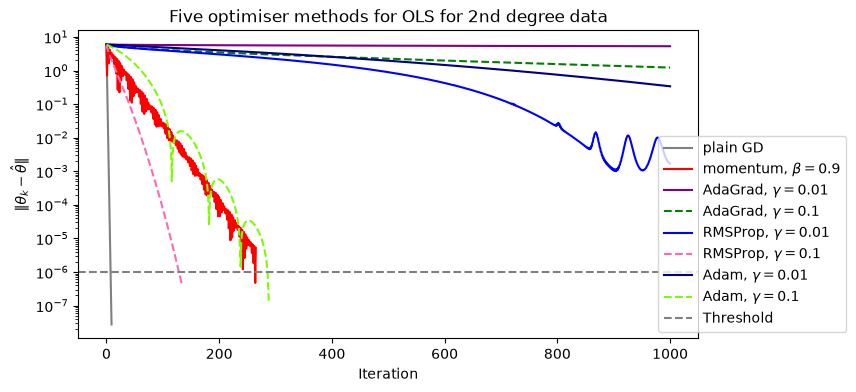

plain GD Converged at 9
momentum, $\beta=0.9$ Converged at 288
AdaGrad, $\gamma = 0.01$ Not converged at 1000
AdaGrad, $\gamma = 0.1$ Not converged at 1000
RMSProp, $\gamma = 0.01$ Not converged at 1000
RMSProp, $\gamma = 0.1$ Converged at 132
Adam, $\gamma = 0.01$ Not converged at 1000
Adam, $\gamma = 0.1$ Converged at 285


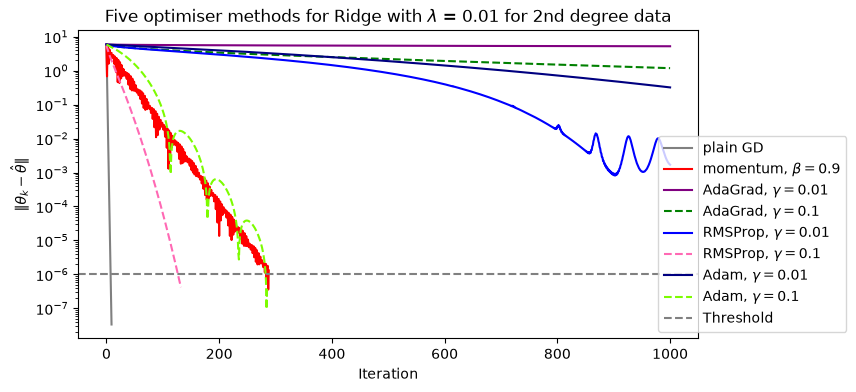

In [8]:
import matplotlib.colors as mcolors

"""Based on Tuesday seminar code"""

#All runs for the specific gammas
deg2_runs = ( ('plain', 0.5, 'gray', '-', 'plain GD'),
              ('momentum', 0.5, 'red', '-', 'momentum, $\\beta=0.9$'),
              ('adagrad', 0.01, 'purple', '-', 'AdaGrad, $\\gamma = 0.01$'),
              ('adagrad', 0.1, 'green', '--', 'AdaGrad, $\\gamma = 0.1$'),
              ('rmsprop', 0.01, 'blue','-', 'RMSProp, $\\gamma = 0.01$'),
              ('rmsprop', 0.1, 'hotpink','--', 'RMSProp, $\\gamma = 0.1$'),
              ('adam', 0.01, 'navy','-', 'Adam, $\\gamma = 0.01$'),
              ('adam', 0.1, 'lawngreen','--', 'Adam, $\\gamma = 0.1$'),
              )


def compare_distance(deg, run, lamba=0.0, num_iters=1500, tol=1e-8):
    X,y = exercise_data(degree=deg)
    theta_cf = closed_form(X,y,lam=lamba)
    grad = lambda th: gradient(th, X, y, lam=lamba)
    out = {}; last_it = {}; status = {}
    for method, gamma, _, _, _ in run:
        g = gamma
        path, final_t = optimise(grad, np.zeros(deg), method, g, num_iters=num_iters, tol=tol)
        distance = np.linalg.norm(path - theta_cf, axis=1)
        out[(method,gamma)] = distance
        last_it[(method,gamma)] = final_t

        err = distance[-1]
        status[(method,gamma)] = 'Converged' if final_t < num_iters and np.isfinite(err) else ('Diverged' if not np.isfinite(err) or err > 1e3 else 'Not converged')
    return out, last_it, status

lambus = 0.01
threshold = 1e-6    #threshold given in exercise


"""OLS"""
deg2_OLS_output, last_it_OLS, status = compare_distance(deg=2, run=deg2_runs, num_iters=1000, tol=threshold)

fig, ax = plt.subplots(figsize=(8,4))
for method, gamma, color, style, label in deg2_runs:
    ax.plot(deg2_OLS_output[method,gamma], linestyle=style, color=color, label=label)
    print(f'{label} {status[method,gamma]} {last_it_OLS[method,gamma]}')

ax.set_title('Five optimiser methods for OLS for 2nd degree data')
ax.axhline(threshold, linestyle='--', color='gray', label='Threshold')
ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\|\theta_k - \hat\theta\|$')
ax.set_yscale('log')
ax.legend(loc='lower right', bbox_to_anchor=(1.25,0))
plt.show()


"""RIDGE """
deg2_R_methods, last_it_R, status = compare_distance(deg=2, run=deg2_runs, lamba=lambus, num_iters=1000, tol=threshold)

fig, ax = plt.subplots(figsize=(8,4))
for method, gamma, color, style, label in deg2_runs:
    ax.plot(deg2_R_methods[method,gamma], linestyle=style, color=color, label=label)
    print(f'{label} {status[method,gamma]} at {last_it_R[method,gamma]}')

ax.set_title(r'Five optimiser methods for Ridge with $\lambda$ = 0.01 for 2nd degree data')
ax.axhline(threshold, linestyle='--', color='gray', label='Threshold')
ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\|\theta_k - \hat\theta\|$')
ax.set_yscale('log')
ax.legend(loc='lower right', bbox_to_anchor=(1.25,0))
plt.show()


### 2b)

Repeat for the degree-5 data ($\kappa = 520$), with $\gamma = 0.9 \cdot 2/\lambda_{\max}$
for plain descent and momentum. Report the number of iterations to reach
$\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\| < 10^{-6}$ for each method,
and identify the method that does not get there at a constant $\gamma$.
Explain why, using your result from exercise 1c).

plain GD with gamma: 0.3184298189253216 Converged 2385
momentum with gamma: 0.3184298189253216 Converged 293
AdaGrad with gamma: 0.01 Not converged 2500
AdaGrad with gamma: 0.1 Not converged 2500
RMSProp with gamma: 0.01 Not converged 2500
RMSProp with gamma: 0.1 Not converged 2500
Adam with gamma: 0.01 Not converged 2500
Adam with gamma: 0.1 Converged 1623


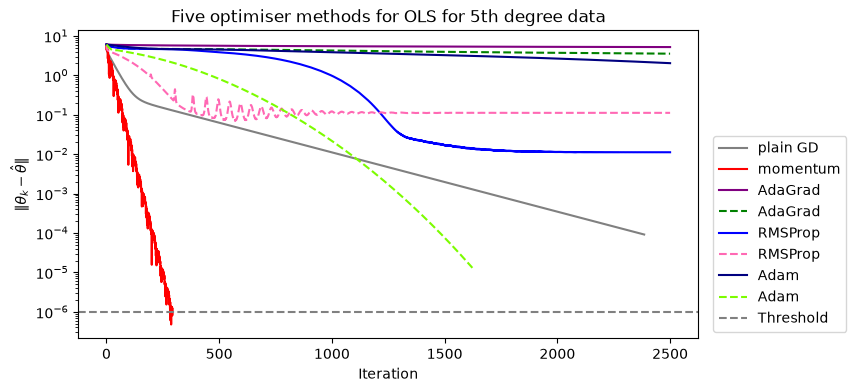

plain GD with gamma: 0.3173071516049962 Converged 841
momentum with gamma: 0.3173071516049962 Converged 285
AdaGrad with gamma: 0.01 Not converged 2500
AdaGrad with gamma: 0.1 Not converged 2500
RMSProp with gamma: 0.01 Not converged 2500
RMSProp with gamma: 0.1 Not converged 2500
Adam with gamma: 0.01 Not converged 2500
Adam with gamma: 0.1 Converged 1407


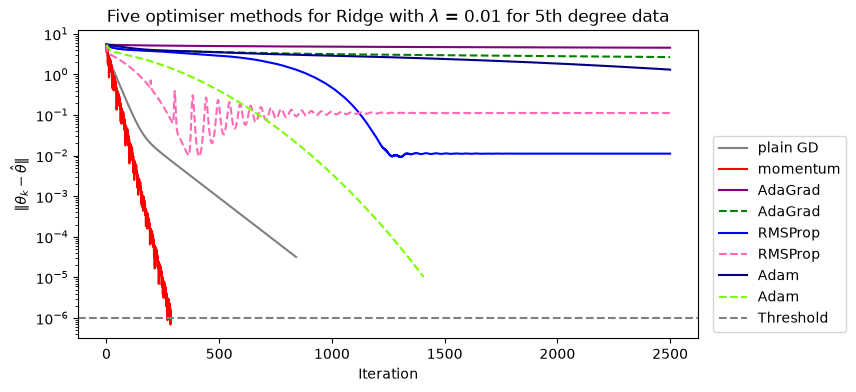

In [9]:
X5, y5 = exercise_data(degree=5)

deg5_OLS_eigs = hessian_eigs(X5)
gamma_OLS = 0.9 * 2 / deg5_OLS_eigs.max()

#New data to run over as gamma_OLS for plain and momentum is different
deg5_runs_OLS = ( ('plain', gamma_OLS, 'gray', '-', 'plain GD'),
              ('momentum', gamma_OLS, 'red', '-', 'momentum'),
              ('adagrad', 0.01, 'purple', '-', 'AdaGrad'),
              ('adagrad', 0.1, 'green', '--', 'AdaGrad'),
              ('rmsprop', 0.01, 'blue','-', 'RMSProp'),
              ('rmsprop', 0.1, 'hotpink','--', 'RMSProp'),
              ('adam', 0.01, 'navy','-', 'Adam'),
              ('adam', 0.1, 'lawngreen','--', 'Adam'),
              )

threshold = 1e-6
deg5_OLS_output, last_it_OLS, status = compare_distance(deg=5, run=deg5_runs_OLS, num_iters=2500,tol=threshold)

fig, ax = plt.subplots(figsize=(8,4))
for method, gamma, color, style, label in deg5_runs_OLS:
    ax.plot(deg5_OLS_output[method,gamma], linestyle=style, color=color, label=label)
    print(f'{label} with gamma: {gamma} {status[method,gamma]} {last_it_OLS[method,gamma]}')

ax.set_title('Five optimiser methods for OLS for 5th degree data')
ax.axhline(threshold, linestyle='--', color='gray', label='Threshold')
ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\|\theta_k - \hat\theta\|$')
ax.set_yscale('log')
ax.legend(loc='lower right', bbox_to_anchor=(1.25,0))
plt.show()

deg5_R_eigs = hessian_eigs(X5, lam=lambus)

gamma_R = 0.9 * 2 / deg5_R_eigs.max()

#New data to run over as gamma_OLS for plain and momentum is different
deg5_runs_R = ( ('plain', gamma_R, 'gray', '-', 'plain GD'),
              ('momentum', gamma_R, 'red', '-', 'momentum'),
              ('adagrad', 0.01, 'purple', '-', 'AdaGrad'),
              ('adagrad', 0.1, 'green', '--', 'AdaGrad'),
              ('rmsprop', 0.01, 'blue','-', 'RMSProp'),
              ('rmsprop', 0.1, 'hotpink','--', 'RMSProp'),
              ('adam', 0.01, 'navy','-', 'Adam'),
              ('adam', 0.1, 'lawngreen','--', 'Adam'),
              )

deg5_R_methods, last_it_R, status = compare_distance(deg=5, run=deg5_runs_R, lamba=lambus, num_iters=2500, tol=threshold)

fig, ax = plt.subplots(figsize=(8,4))
for method, gamma, color, style, label in deg5_runs_R:
    ax.plot(deg5_R_methods[method,gamma], linestyle=style, color=color, label=label)
    print(f'{label} with gamma: {gamma} {status[method,gamma]} {last_it_R[method,gamma]}')

ax.set_title(r'Five optimiser methods for Ridge with $\lambda$ = 0.01 for 5th degree data')
ax.axhline(threshold, linestyle='--', color='gray', label='Threshold')
ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\|\theta_k - \hat\theta\|$')
ax.set_yscale('log')
ax.legend(loc='lower right', bbox_to_anchor=(1.25,0))
plt.show()


### 2c)

Check one method against a library implementation: for the degree-2 OLS
problem, run `optax.adam` (or `torch.optim.Adam`, or any other) with the same
$\gamma$, $\beta_1$, $\beta_2$ and $\epsilon$ from the same starting point, and
compare the first ten iterates with your own. They should agree to rounding.
If they do not, the usual suspects are the bias correction and the placement
of $\epsilon$ (inside or outside the square root).

In [10]:
"""Check method Adam vs degree-2 OLS"""
import jax
import jax.numpy as jnp
import optax

"""Data for both"""
gamma = 0.1
beta1 = 0.9;    beta2 = 0.999
eps = 1e-8

X2, y2 = exercise_data(degree=2)


"""Own Adam"""
grad = lambda theta: gradient(theta, X2,y2)
state = {}
theta = np.zeros(X2.shape[1])
own_hist = [theta]

for t in range(1,11):
    g = grad(theta)
    theta, state = optimiser_step('adam', theta, g, state, t, gamma, beta1=beta1, beta2=beta2, eps=eps)
    own_hist.append(theta)


"""Optax Adam based on optax.adam from optax-redthedocs.io"""
solver = optax.adam(learning_rate=gamma, b1=beta1, b2=beta2, eps=eps)

def cost_OLS(theta, X, y):
    return jnp.sum(( X @ theta - y)**2) / len(y)

thetas = jnp.zeros(X2.shape[1])
opt_state = solver.init(thetas)
optax_hist = [thetas] 

for i in range(1,11):
    grad = jax.grad(cost_OLS)(thetas, X2, y2)
    updates, opt_state = solver.update(grad, opt_state, thetas)
    thetas = optax.apply_updates(thetas, updates)
    optax_hist.append(thetas)

print(f'{'t':<3} | {'Own Code Adam':<25} | {'Optax Code Adam':<25} | Difference ')
for i in range(10):
    diff = np.linalg.norm(own_hist[i] - optax_hist[i])
    own_str = np.array2string(own_hist[i], precision=7, floatmode='fixed', suppress_small=True)
    optax_str = np.array2string(optax_hist[i], precision=7, floatmode='fixed', suppress_small=True)
    print(f'{i+1:<3} | {own_str:<25} | {optax_str:<25} | {diff:<10.3e} ' )

t   | Own Code Adam             | Optax Code Adam           | Difference 
1   | [0.0000000 0.0000000]     | [0.0000000 0.0000000]     | 0.000e+00  
2   | [-0.1000000  0.1000000]   | [-0.0999993  0.0999993]   | 9.431e-07  
3   | [-0.1984977  0.1999566]   | [-0.1984961  0.1999549]   | 2.329e-06  
4   | [-0.2937203  0.2998398]   | [-0.2937185  0.2998377]   | 2.763e-06  
5   | [-0.3830673  0.3996189]   | [-0.3830647  0.3996159]   | 3.931e-06  
6   | [-0.4631118  0.4992621]   | [-0.4631088  0.4992582]   | 4.888e-06  
7   | [-0.5301127  0.5987365]   | [-0.5301099  0.5987321]   | 5.175e-06  
8   | [-0.5811085  0.6980073]   | [-0.5811061  0.6980022]   | 5.733e-06  
9   | [-0.6149667  0.7970382]   | [-0.6149648  0.7970323]   | 6.201e-06  
10  | [-0.6325668  0.8957907]   | [-0.6325656  0.8957841]   | 6.781e-06  


## Exercise 3: the learning rate means something different to each method

### 3a)

For the degree-5 OLS problem, scan $\gamma$ over a logarithmic grid from
$10^{-3}$ to $1$ (about fifteen values) for each of the five methods, and
record the number of iterations to $\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\| < 10^{-6}$
(or "did not converge" within 20 000 iterations). Plot iterations against
$\gamma$ for all methods in one figure, on logarithmic axes.

### 3b)

Discuss the figure: where does each method's window of usable $\gamma$ start
and end, and how do the edges relate to $2/\lambda_{\max}$ (plain descent),
$2(1+\beta)/\lambda_{\max}$ (momentum), and to the fact that the adaptive
methods take steps of length at most $\gamma$ per coordinate? Which method is
the least sensitive to $\gamma$, and is it also the fastest at its best
$\gamma$?

### 3c)

Book Table 4.1 and Figure 4.7 compare the five methods at three learning
rates on a problem with $\kappa = 12$ and find that the ranking reverses
between $\gamma = 0.01$ and $\gamma = 0.5$. Reproduce this behaviour on your
degree-2 data (where $\kappa = 1.3$): which method is best at each $\gamma$, and
what is the lesson for how optimisers should be compared in Project 1?

In [11]:
# Your code for exercise 3 here

#3a 
gammas = np.linspace(1e-3, 1, 15)

FUNCT_RUNS = (('plain', gammas, '#777777', 'plain GD'),
            ('momentum', gammas, '#004488', 'momentum, $\\beta=0.9$'),
            ('adagrad', gammas, '#DDAA33', 'AdaGrad, $\\gamma=0.5$'),
            ('rmsprop', gammas, '#228833', 'RMSProp, $\\gamma=0.01$'),
            ('adam', gammas, '#BB5566', 'Adam, $\\gamma=0.05$'))


def funct_comparison(degree=5, num_iters=30000, lam = 0.0):
    """Excess cost C(theta_k) - C(theta_hat) for the five optimisers on the Runge problem."""
    X, y = exercise_data(degree=degree)
    theta_cf = closed_form(X, y, lam = lam) #the estimator, OLS if lam = 0, ridge otherwise
    print(f"{theta_cf.shape = } , {X.shape=}, {y.shape=}")
    c_min = cost(theta = theta_cf, X = X, y = y, lam = lam) #the cost fucntion
    eigs = hessian_eigs(X, lam = lam) # gets the eigenvalues of the hessian
    gamma_gd = 0.9 * 2.0 / eigs.max() # sets a gamma to be used if none is given based on the limit 2/lambda_max
    grad = lambda th: gradient(th, X, y) #defines the gradient fuct 
    out = {}  #dict that stores the outputs for each method
    for method, gammas_, _, _ in FUNCT_RUNS:
        out_gammas = {}
        for gamma in gammas_:
            g = gamma_gd if gamma is None else gamma
            path, _ = optimise(grad, np.zeros(degree), method, g, num_iters=num_iters) #uses the diff optimisers
            out_gammas[gamma] = np.array([cost(th, X, y) - c_min for th in path]) #gives the excess per gamma
        out[method] = out_gammas
    return out, eigs, gamma_gd


In [14]:
excess5, eigs5, gamma5 = funct_comparison(degree=5, num_iters=30000)
tolerances = (1e-4, 1e-8)
iterations = {}
for method, gammas_, _, _ in FUNCT_RUNS:
    e_ = excess5[method]
    its_per_gamma = {}
    for gamma in gammas_:
        e = e_[gamma] #accesssing the excess per method per learning rate gamma
        its_per_gamma[gamma] = {tol: (int(np.argmax(e < tol)) if (e < tol).any() else None) for tol in tolerances}
        print(f"{method:8s} (gamma = {gamma5 if gamma is None else gamma:.3f}): to 1e-4: {its_per_gamma[gamma][1e-4]}, to 1e-8: {its_per_gamma[gamma][1e-8]}, "
            f"after 20000: {max(e[-1], 0):.1e}")
    iterations[method] = its_per_gamma

    

theta_cf.shape = (5,) , X.shape=(100, 5), y.shape=(100,)


C:\Users\perni\AppData\Local\Temp\ipykernel_22908\2862816977.py:20: RuntimeWarning: overflow encountered in square
  return np.sum((X @ theta - y) ** 2) / len(y) + lam * theta @ theta
C:\Users\perni\AppData\Local\Temp\ipykernel_22908\2862816977.py:25: RuntimeWarning: overflow encountered in matmul
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta
C:\Users\perni\AppData\Local\Temp\ipykernel_22908\2862816977.py:25: RuntimeWarning: invalid value encountered in matmul
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta
C:\Users\perni\AppData\Local\Temp\ipykernel_22908\2862816977.py:25: RuntimeWarning: invalid value encountered in multiply
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta
C:\Users\perni\AppData\Local\Temp\ipykernel_22908\2862816977.py:20: RuntimeWarning: overflow encountered in matmul
  return np.sum((X @ theta - y) ** 2) / len(y) + lam * theta @ theta
C:\Users\perni\AppData\Local\Temp\ipykernel_22908\2862816977.py:20: RuntimeWarning: in

plain    (gamma = 0.001): to 1e-4: None, to 1e-8: None, after 20000: 7.6e-03
plain    (gamma = 0.072): to 1e-4: 1231, to 1e-8: 7080, after 20000: 4.6e-15
plain    (gamma = 0.144): to 1e-4: 620, to 1e-8: 3564, after 20000: 4.4e-15
plain    (gamma = 0.215): to 1e-4: 414, to 1e-8: 2381, after 20000: 4.4e-15
plain    (gamma = 0.286): to 1e-4: 311, to 1e-8: 1787, after 20000: 4.5e-15
plain    (gamma = 0.358): to 1e-4: None, to 1e-8: None, after 20000: inf
plain    (gamma = 0.429): to 1e-4: None, to 1e-8: None, after 20000: nan
plain    (gamma = 0.500): to 1e-4: None, to 1e-8: None, after 20000: nan
plain    (gamma = 0.572): to 1e-4: None, to 1e-8: None, after 20000: nan
plain    (gamma = 0.643): to 1e-4: None, to 1e-8: None, after 20000: nan
plain    (gamma = 0.715): to 1e-4: None, to 1e-8: None, after 20000: nan
plain    (gamma = 0.786): to 1e-4: None, to 1e-8: None, after 20000: nan
plain    (gamma = 0.857): to 1e-4: None, to 1e-8: None, after 20000: nan
plain    (gamma = 0.929): to 1e-4:

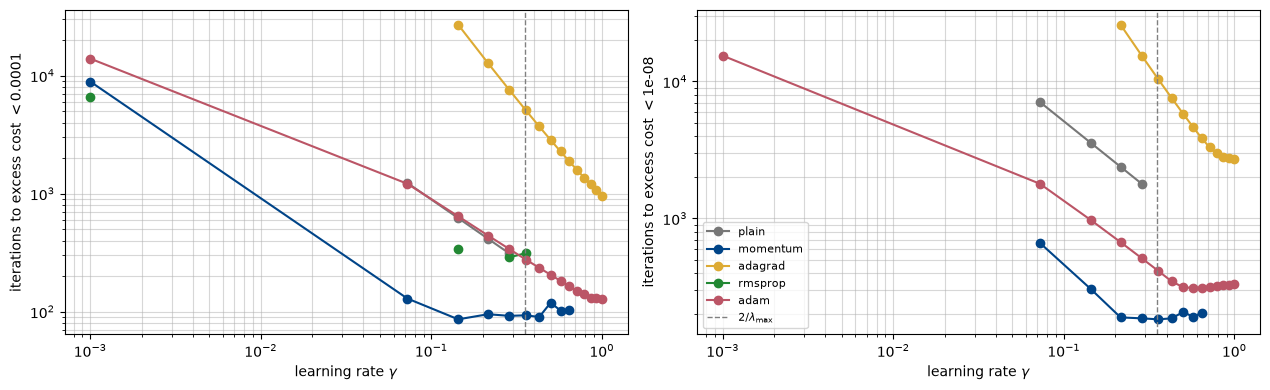

In [16]:
#plotting iterations agains gammas for al methods on log axes

e_ = excess5[method]

fig, axs = plt.subplots(1, len(tolerances),  figsize=(6.4*len(tolerances), 4.0))
# fig, axs = plt.subplots(len(tolerances),1,  figsize=(6.4, 4.0*len(tolerances)))
for ax, tolerance in zip(axs,tolerances):
    for method, gammas_, col, _ in FUNCT_RUNS:
        its = np.array([
            np.nan if iterations[method][gamma][tolerance] is None
            else iterations[method][gamma][tolerance]
            for gamma in gammas_
        ])

        ax.loglog(gammas_, its, "o-", color=col, label=method)
    ax.axvline(2 / eigs5.max(), color="grey", ls="--", lw=1, label=r"$2/\lambda_{\max}$")
    ax.set_ylabel(r"iterations to excess cost $<$" +f"{tolerance}")
    ax.set_xlabel(r"learning rate $\gamma$"); 
    ax.grid(alpha = 0.5, which = 'both')
axs[-1].set_xlabel(r"learning rate $\gamma$"); 

ax.legend(fontsize=8); fig.tight_layout()
plt.show()

## Exercise 4: stochastic gradient descent

Replace the full gradient by a minibatch gradient, Eq. (4.33), inside an
epoch loop. Reshuffle the data every epoch and split the shuffled indices into
minibatches of size $M$; the update of Eq. (4.34) is one call to your
`optimiser_step`, so every optimiser of exercise 2 works with minibatches
unchanged.

In [17]:
def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]

def step_length(t, t0, t1):
    """The schedule of Eq. (4.40)."""
    return t0 / (t + t1)

def sgd(X, y, method="plain", n_epochs=50, batch_size=5, gamma=0.1, schedule=None, lam=0.0, seed=2026, **kw):
    """Minibatch SGD, Eq. (4.34), with any optimiser. schedule=(t0, t1) replaces gamma by Eq. (4.40).
    Returns the iterate after every epoch."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta, state, t = np.zeros(p), {}, 0
    history = [theta.copy()]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):
            t += 1
            g = gradient(theta, X[batch], y[batch], lam)                                   # the gradient of the cost on this minibatch
            gamma_t = gamma if schedule is None else step_length(t, *schedule)                            # constant, or the schedule
            theta, state = optimiser_step(method, theta, g, state, t, gamma_t, **kw)
        history.append(theta.copy())
    return np.array(history)

### 4a)

At a fixed point $\boldsymbol{\theta} = (0, 3)$ of the degree-2 problem,
compute the gradient on many random minibatches of size $M = 1, 5, 25$ and
compare their mean and their spread (standard deviation over batches) with the
full gradient. Verify numerically that the spread falls as $1/\sqrt{M}$, and say
in one sentence what this means for the trade-off between batch size and cost
per step.

*Answer:* larger number of batches shrinks gradient noise but increases computational cost. If we increase batch size by 25, the cost increases by 25 times, but the noise is reduced only by 1/$\sqrt{M}$ = 5 times. 

### 4b)

Run plain SGD with $M = 5$ on the degree-2 data for 100 epochs at
$\gamma = 0.1$ and at $\gamma = 0.02$, and plot the distance to the closed-form
solution against the number of *single-point gradient evaluations* (epochs
times $n$) together with full-batch gradient descent at $\gamma = 0.5$. Which
method is ahead early, which is ahead late, and does SGD with a constant
learning rate converge at all? Relate the size of the plateau to $\gamma$.

*Answer:* very early we can see that the lower learning rate, $\gamma = 0.02$ is ahead, but is very quickly overtaken by the higher learning rate of $\gamma = 0.1$. The plot with the higher learning rate, for the SGD, plateues higher than the lower one, because the higer learning rate means we are taking larger steps toward the minimum. With the lower learning rate, it takes longer to reach the optimum value, but we get a value that is closer to the true minimum than with the higer learning rate. 

For the full-batch GD, there is no noise because every step uses the expact gradient of the data. We can see that the SGD dont reach an as low value as the full-batch GD, they rather hover in a plateau higher up.


### 4c)

Now the schedule of Eq. (4.40). With $(t_0, t_1) = (1, 10)$ the initial
learning rate is $0.1$. Add this run to the plot of 4b). Then move to the
degree-5 data and run the same schedule: what happens? Find a pair $(t_0, t_1)$
with the same initial learning rate that works there, and explain your choice
in terms of the Robbins–Monro conditions $\sum_t \gamma_t = \infty$,
$\sum_t \gamma_t^2 < \infty$.

*Answer:* For the degree-5 data we plataeu far from the optimum value that we reached for the degree-2 case. This is because the learning rate stays close to its initial for many iterations at the start, before decaying when we have a higher degree. 

The best pair $(t_0, t_1)$ with the same inital learning rate will be the one where the final distance is close to the initial learning rate. Here we tried $(t_0, t_1) = (50, 500)$ which gave us a final distance of 0.16, which is quite close to the initial learning rate. 

All the pairs we tested satisfy the RObbins Monro conditions, as we can see since none of them diverge. 

### 4d)

Study the batch size on the degree-5 data at $\gamma = 0.1$: $M \in \{1, 5, 20, 100\}$
for 100 epochs. One of these runs diverges although $\gamma$ is below
$2/\lambda_{\max}$ of the full Hessian. Which Hessian is relevant for a single
minibatch step, and what is its largest eigenvalue for $M = 1$? (For a single
point it is $2\|\boldsymbol{x}_i\|^2$.)

### 4e)

Combine SGD with Adam on the degree-5 data ($M = 5$, $\gamma \in \{0.01, 0.05\}$,
100 epochs) and compare with plain SGD and with momentum. Which combination
comes closest to the closed-form solution, and which one fails? This is the
setting of Project 1, part h).

full gradient: [ 1.47833066 -5.45421202]
M = 1: mean = [ 1.478 -5.454], |bias| = 4.895e-14, spread = 8.477
M = 5: mean = [ 1.478 -5.454], |bias| = 4.578e-15, spread = 3.700
M = 25: mean = [ 1.478 -5.454], |bias| = 2.674e-15, spread = 1.508


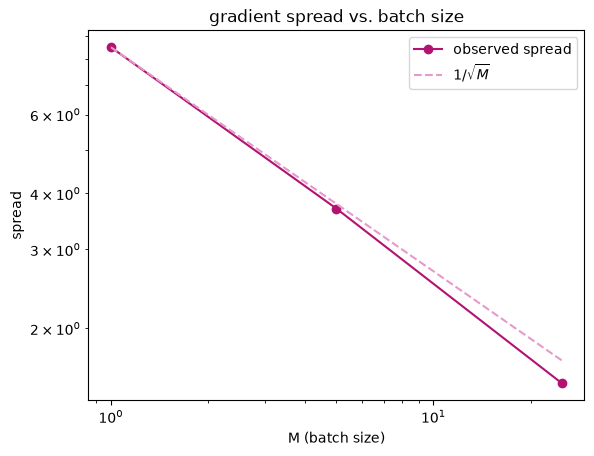

In [18]:
"""Exercise 4a"""

X, y = exercise_data(degree = 2)
n = len(y)
theta = np.array([0.0, 3.0])
theta_cf = closed_form(X, y)

g_full = gradient(theta, X, y)
rng = np.random.default_rng(2026)

print(f'full gradient: {g_full}' )

spreads = {}

for M in (1, 5, 25):
    gs = np.array([gradient(theta, X[b], y[b]) for _ in range(50) for b in make_batches(n, M, rng)])
    mean = gs.mean(axis = 0)
    spreads[M] = gs.std(axis = 0).mean()

    bias = mean - g_full

    print(f'M = {M}: mean = {np.round(mean, 3)}, |bias| = {np.linalg.norm(bias):.3e}, spread = {spreads[M]:.3f}')


Ms = list(spreads.keys())
observed = [spreads[M] for M in Ms]
s1 = spreads[1]
predicted = [s1 / np.sqrt(M) for M in Ms]


plt.plot(Ms, observed, 'o-', label = "observed spread", color = "#B21372")
plt.plot(Ms, predicted, '--', label = r'$1/\sqrt{M}$', color = "#E699CB")
plt.xlabel("M (batch size)")
plt.ylabel("spread")
plt.xscale("log")
plt.yscale("log")
plt.title("gradient spread vs. batch size")
plt.legend()
plt.show()


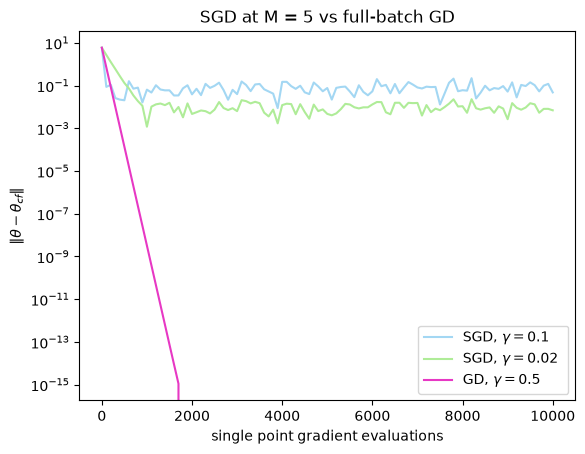

In [19]:
"""Exercise 4b"""

M = 5
gammas = [0.1, 0.02]
n_epoch = 100


#sgd with different gammas at M = 5
distances = {}
for gamma in gammas:
    hist = sgd(X, y, n_epochs = n_epoch, batch_size = M, gamma = gamma)
    distances[gamma] = np.linalg.norm(hist - theta_cf, axis = 1)


#full batch gradient descent
gamma_gd = 0.5
hist_gd = sgd(X, y, n_epochs=n_epoch, batch_size=n, gamma = gamma_gd)
distances['GD'] = np.linalg.norm(hist_gd - theta_cf, axis = 1)


#single point gradient evaluations
epochs = np.arange(n_epoch + 1)
x_gd = epochs * n
x_sgd = epochs * n


#plots
colors = ["#A3D7F3", "#AFEC98"]
for gamma, color in zip(gammas, colors):
    plt.plot(x_sgd, distances[gamma], label = fr"SGD, $\gamma = {gamma}$ ", color = color )
plt.plot(x_gd, distances['GD'], label = fr"GD, $\gamma = {gamma_gd}$" , color = "#E738C4")
plt.yscale("log")
plt.xlabel("single point gradient evaluations")
plt.ylabel(r'$\|\theta - \theta_{cf}\|$')
plt.title("SGD at M = 5 vs full-batch GD")
plt.legend()
plt.show()



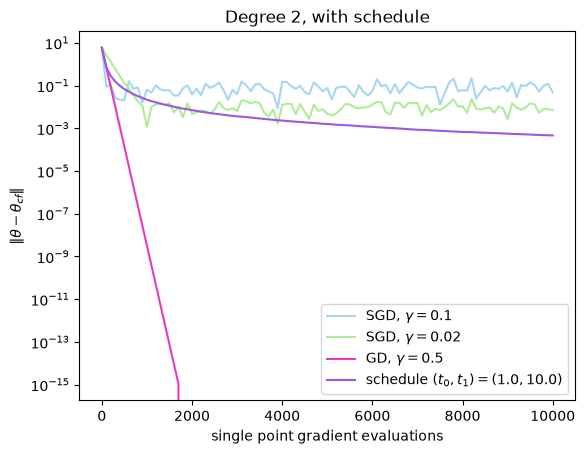

(1.0, 10.0): final = 2.9843, diverged = False
(5.0, 50.0): final = 1.1102, diverged = False
(20.0, 200.0): final = 0.2521, diverged = False
(50.0, 500.0): final = 0.1609, diverged = False


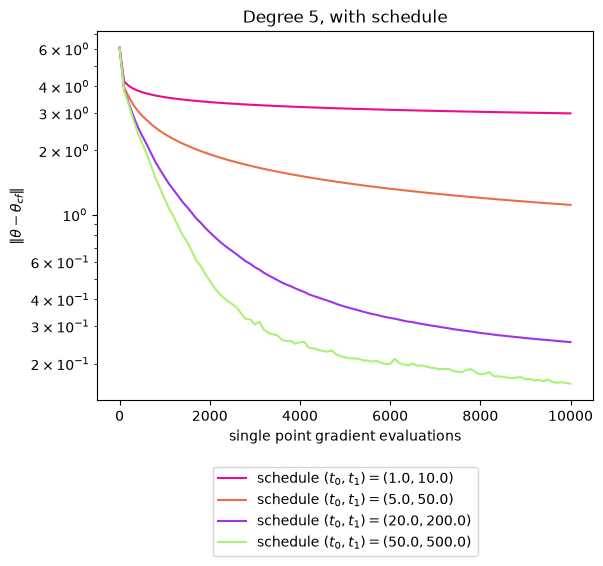

In [20]:
"""Exercise 4c"""

#for degree 2 and 5
distances_degree = {}

for degree in (2, 5):
    Xd, yd = exercise_data(degree = degree)
    theta_d = closed_form(Xd, yd)

    #different scheduels
    candidates = [(1.0, 10.0), (5.0, 50.0), (20.0, 200.0), (50.0, 500.0)]
    scheduels = [(1.0, 10.0)] if degree == 2 else candidates

    distances_degree[degree] = {}
    for sched in scheduels:
        hist = sgd(Xd, yd, n_epochs=n, batch_size=M, schedule = sched) 
        d = np.linalg.norm(hist - theta_d, axis = 1)
        distances_degree[degree][sched] = d

#plots for degree 2
x_axis = np.arange(n + 1) * n

gammas = [0.1, 0.02]
colors = ["#A3D7F3", "#AFEC98"]
for gamma, color in zip(gammas, colors):
    plt.plot(x_sgd, distances[gamma], label = fr"SGD, $\gamma = {gamma}$ ", color = color )
plt.plot(x_gd, distances['GD'], label = fr"GD, $\gamma = {gamma_gd}$" , color = "#E738C4")

for sched, d in distances_degree[2].items():
    plt.plot(x_axis, d, label = fr'schedule $(t_0, t_1) = {sched}$', color = "#9C58E0")

plt.yscale("log")
plt.xlabel("single point gradient evaluations")
plt.ylabel(r'$\|\theta - \theta_{cf}\|$')
plt.title("Degree 2, with schedule")
plt.legend()
plt.show()


#plots for degree 5

for sched in candidates:
    d = distances_degree[5][sched]
    diverged = np.any(~np.isfinite(d)) or d[-1] > 10*d[0]
    print(f'{sched}: final = {d[-1]:.4f}, diverged = {diverged}')

colors5 = ["#ED0A8B", "#EA6E45", "#9F32ED","#A9F274" ]
for (sched, d), color in zip(distances_degree[5].items(), colors5):
    #print(f'{sched}: final distance = {d[-1]:.4f}, initial distance = {d[0]:.4f}')
    plt.plot(x_axis, d, label = fr'schedule $(t_0, t_1) = {sched}$', color = color)
    
#plt.axhline(0.1*np.linalg.norm(theta_d), linestyle = "--", color = "gray", alpha = 0.5, label = "threshold")
plt.yscale("log")
plt.xlabel("single point gradient evaluations")
plt.ylabel(r'$\|\theta - \theta_{cf}\|$')
plt.title("Degree 5, with schedule")
plt.legend(loc = 'center', bbox_to_anchor = (0.5, -0.3))
plt.show()

## Exercise 5: the Runge function at degree 10 (Project 1, parts f and h)

Last week nothing converged on the Runge function $f(x) = 1/(1+25x^2)$ on
$[-1, 1]$ ($n = 100$, noise $0.1$) with a degree-10 polynomial:
$\kappa \approx 2 \times 10^6$. Use the Tuesday session's `runge_data` (the same
standardisation as above).

### 5a)

Run momentum and Adam with the full gradient for 30 000 iterations and plot
the excess cost $C(\boldsymbol{\theta}_k) - C(\hat{\boldsymbol{\theta}}_{\mathrm{OLS}})$
against the iteration. What accuracy do they reach, and does either of them
resolve the flat directions? Explain, with the rotated bowl of the Tuesday
session in mind, why a diagonal rescaling cannot fix a problem whose
ill-conditioning comes from strongly correlated columns.

### 5b)

Add Ridge with $\lambda \in \{10^{-3}, 10^{-2}\}$: what are the condition
numbers now, and how many iterations do momentum and Adam need to reach an
excess cost of $10^{-8}$? Compare the Ridge coefficients with the OLS ones and
discuss whether Ridge is "cheating" — what problem has it solved, and is that
the problem you wanted solved? (Part i) of Project 1 answers the last question
with cross-validation.)

### 5c)

Take one Newton step from $\boldsymbol{\theta}_0 = \boldsymbol{0}$ with the exact
Hessian $\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}$ — or, following week 37, with
`jax.hessian` of your cost — and compare with the closed form. What did Newton
use that none of the first-order methods had, and why can we not simply do
this for a neural network?

### 5d)

Finally, minibatches: run SGD with Adam ($M = 10$, a decaying schedule of
your choice, 500 epochs) on the degree-10 problem and compare the excess cost
per gradient evaluation with the full-gradient Adam run of 5a). Give a
critical assessment, in the spirit of part h) of Project 1: what has the noise
bought, and what has it cost?

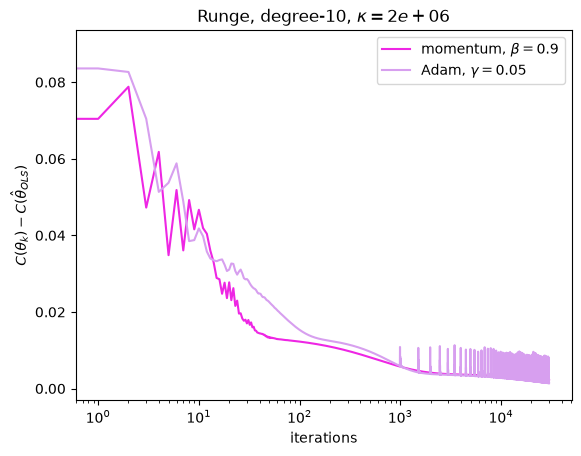

In [21]:
"""Exercise 5a"""

kappa = 2e6

def runge_data(n=100, degree=10, noise=0.1, seed=2026):
    """Runge function 1/(1+25x^2) on [-1,1], standardised polynomial features, centred y."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1.0, 1.0, n)
    y = 1.0 / (1.0 + 25.0 * x**2) + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()


RUNGE_RUNS = ( ('momentum', None, "#EE26E4", 'momentum, $\\beta=0.9$'), ('adam', 0.05, "#D79FEF", 'Adam, $\\gamma=0.05$'))

def runge_comparison(degree=10, num_iters=30000):
    """Excess cost C(theta_k) - C(theta_hat) for the five optimisers on the Runge problem."""
    X, y = runge_data(degree=degree)
    theta_cf = closed_form(X, y)
    c_min = cost(theta_cf, X, y)
    eigs = hessian_eigs(X)
    gamma_gd = 0.9 * 2.0 / eigs.max()
    grad = lambda th: gradient(th, X, y)
    out = {}
    for method, gamma, _, _ in RUNGE_RUNS:
        g = gamma_gd if gamma is None else gamma
        path, n_steps = optimise(grad, np.zeros(degree), method, g, num_iters=num_iters)
        out[method] = np.array([cost(th, X, y) - c_min for th in path])
    return out, eigs, gamma_gd

excess10, eigs10, gamma10 = runge_comparison(degree = 10, num_iters=30000)

for method, gamma, color, label in RUNGE_RUNS:
    plt.plot(excess10[method], label = label, color = color)

plt.xscale("log")
plt.xlabel("iterations")
plt.ylabel(r'$C(\theta_k) - C(\hat\theta_{OLS})$')
plt.title(f'Runge, degree-10, $\\kappa = {kappa:.0e}$')
plt.legend()
plt.show()


## Insights you should have gained this week — a self-check

Before you hand in, go through the list below without looking at the notes.
Each row is a question we may ask in the Tuesday session or on Project 1; the
right-hand column is the insight it tests, in one sentence.

| Ask yourself | The insight it tests |
|---|---|
| Adam converged for every learning rate from $10^{-3}$ to $1$ and plain gradient descent only in a narrow window. Does $\gamma$ not matter for Adam? | It matters for speed, not for stability: the adaptive step is at most $\gamma$ per coordinate (division by $\sqrt{\hat v}$), so $\gamma$ is a *length in parameter space* and cannot violate Eq. (4.20) — but the best $\gamma$ was still several times faster than the worst. |
| RMSProp at a constant $\gamma$ never reached $10^{-6}$ on a convex quadratic. Why? | Near the minimum $r \approx g^2$ and the step is $\approx \gamma\,\mathrm{sign}(g)$, a fixed length that cannot shrink: the iterate rattles at radius $\sim\gamma$. It needs a decaying $\gamma$ (Eq. 4.40), or the first moment — which is Adam. |
| AdaGrad was slower than plain gradient descent on the degree-6 Runge problem. Is it broken? | No: $\boldsymbol{r}_t$ never forgets, Eq. (4.42), so the effective learning rate decays like $1/\sqrt t$ whether or not the minimum is near. That is the wrong behaviour on a smooth convex problem and the right one for sparse features, which it was designed for. |
| Why does Adam divide its moments by $1 - \beta_i^t$? | Both averages start from zero, so $\mathbb{E}[v_t] = (1-\beta_2^t)\,\mathbb{E}[g^2]$, Eq. (4.53): at $t=1$ the raw second moment is a thousand times too small and the step would be $\sqrt{1000}/\sqrt{10}\approx 3$ times too long. Dividing by the known factor removes the bias exactly; for large $t$ the correction vanishes. |
| What does "adaptive" mean, in one sentence? | Each coordinate gets its own step $\gamma/\sqrt{v_j}$, with $v_j$ the recent mean square gradient as a proxy for the curvature $\lambda_j$: a diagonal, $\mathcal{O}(p)$ imitation of Newton's $\boldsymbol{H}^{-1/2}$ (Section 4.8). |
| Rotating the bowl by $45^\circ$ left plain gradient descent unchanged and made AdaGrad and RMSProp fail. Why? | Eq. (4.19) depends on the eigenvalues only, which a rotation preserves; the adaptive methods rescale *coordinates* and see only the diagonal of $\boldsymbol{H}$. A valley that is not axis-aligned — a correlated polynomial basis, for instance — has its curvature off the diagonal. |
| Every first-order method stalled at an excess cost of $10^{-3}$ on the degree-10 Runge problem, and one Newton step solved it. What did Newton have? | The full Hessian, off-diagonal entries included: $\kappa = 2\times10^6$ is invisible to it, Eq. (4.8). We cannot afford it for a network ($\mathcal{O}(p^3)$); every method from momentum to Adam is a cheaper approximation to it. |
| Book Table 4.1: no optimiser is best at the same $\gamma$ as any other. What does that mean for comparing methods? | A learning rate is not comparable across optimisers — plain descent multiplies the gradient by $\gamma$, the adaptive methods normalise it first. Compare methods at each one's *best* $\gamma$, found by a scan, never at one shared value. |
| Plain SGD with $M=5$ sat at a distance $5\times10^{-2}$ from the minimum for ninety epochs. Has it converged? | No, it has equilibrated: the minibatch gradient is an unbiased estimate with noise $\propto 1/\sqrt M$ (Section 2.5), and at constant $\gamma$ the iterate is a random walk in a cloud of radius $\propto\sqrt\gamma/\sqrt M$. A longer run does not help; a smaller $\gamma$, a larger $M$ or a decaying $\gamma_t$ does. |
| Full-batch gradient descent beat SGD per gradient evaluation on the degree-2 data. Is SGD overrated? | On a small benign problem the exact gradient is cheap and converges geometrically, Eq. (4.26). For $n = 10^6$ one full gradient costs $10^4$ minibatch steps: per unit of computation SGD is far ahead, and it never needs the whole data set in memory — which is why every framework is built on minibatches. |
| The schedule $(t_0,t_1)=(1,10)$ worked at degree 2 and froze at degree 5. Which condition did it break? | Robbins–Monro needs $\sum_t\gamma_t = \infty$; in a finite run $\gamma_t = t_0/(t+t_1)$ with a small $t_1$ decays so fast that the accumulated step cannot cross a $\kappa = 520$ valley. Keep $\gamma_0 = t_0/t_1$ and enlarge both, so the decay starts later. |
| SGD with $M=1$ diverged at a $\gamma$ below $2/\lambda_{\max}$ of the full Hessian. How? | A minibatch step sees the Hessian of the *minibatch* cost; for one point it is $2\boldsymbol{x}_i\boldsymbol{x}_i^T$ with eigenvalue $2\|\boldsymbol{x}_i\|^2$, far above the average. The full-batch bound is a bound on the average, not on every step. |
| When should I stop a stochastic run? | Not on the gradient: monitor the validation cost and stop when it rises while the training cost still falls (early stopping, Section 4.7.1) — a regularisation method as much as a termination rule. |


### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 18 at midnight**. Collaboration is encouraged — list
your collaborators.